In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import io, segmentation, measure
from pathlib import Path

### Turn affine transformation interpolation border into cell mask values via expansion (07172026)

In [2]:
def remove_interp_pixels(img: np.ndarray):
    """
    Args: 3D Cell mask image (t,y,x) with non-integer, interpolated pixels.
    Outputs: Cell mask image with said pixel values set to zero.
    """
    # (time,yaxis,xaxis)=img.shape
    # for t in range(time):
    #     for y in range(yaxis):
    #         for x in range(xaxis):
    #             if img[t,y,x]%1!=0:
    #                 img[t,y,x]=0

    nonints= (img%1!=0)
    img[nonints]=0

    return img 


In [3]:
img_affpath=r'C:\Users\jglic\Downloads\08132026 3c-ey2795\cell_segment\BF-timelapse_08132026_3c-ey2795_glucose-2.0_fov1_segm-afftransf.tif'
img_aff=io.imread(img_affpath)
# img_aff=io.imread(r'C:\Users\jglic\Downloads\07152026 3c-ey2795\cell_segment\BF-timelapse_07152026_3c-ey2795_glucose-2.0_fov1_segm-afftransf-nointerp.tif')

img_nobord=remove_interp_pixels(img_aff)
io.imsave(Path(img_affpath).parent/Path(Path(img_affpath).stem+'-nobord.tif'),img_nobord)

#expand twice in succession to better divvy up bud neck region between mother and daughter
for t in range(img_nobord.shape[0]):
    img_nobord[t,:,:]=segmentation.expand_labels(img_nobord[t,:,:], distance=1) 
    img_nobord[t,:,:]=segmentation.expand_labels(img_nobord[t,:,:], distance=1) 

io.imsave(Path(img_affpath).parent/Path(Path(img_affpath).stem+'-expand.tif'), img_nobord)
# io.imsave(r'C:\Users\jglic\Downloads\07152026 3c-ey2795\cell_segment\BF-timelapse_cpsam-d25_afftransf-nointerp-expand-1.tif',img_expand)

In [14]:
labels3d = np.array(
    [[[0, 1, 0, 0],
     [2, 0, 0, 0],
     [0, 3, 0, 0]],
     [[0, 0, 0, 0],
     [0, 0, 0, 0],
     [0, 0, 0, 0]]]
)
labels3d[0,:,:]=segmentation.expand_labels(labels3d[0,:,:], 1)


In [15]:
labels3d

array([[[2, 1, 1, 0],
        [2, 2, 0, 0],
        [2, 3, 3, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]])

### Compare cell mask size distributions between raw and affine-transformed w/ expansion bright-field time series (0720206)
1. Plot both cell area and difference in cell area (between the two workflows) distributions 

In [2]:
#no preprocessing (e.g., removing dead or excluded cells) on either dataset bc didn't run affine-transformed img through Cell-ACDC

# rawmaskdata=pd.read_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high res\BF-timelapse_acdc_output_cpsam-d25.csv')
# affmask=io.imread(r'C:\Users\jglic\Downloads\06102026 myo1 high res\BF-timelapse_segm_06102026_afftransf_cpsam-d12.tif')
# expsnmask=io.imread(r'C:\Users\jglic\Downloads\06102026 myo1 high res\BF-timelapse_cpsam-d25_afftransf-TEST2.tif')

rawdata_path=r'C:\Users\jglic\Downloads\07172026 myo1 high res\BF-timelapse_acdc_output_07172026_cpsam-d25-ms20.csv'
rawmaskdata=pd.read_csv(rawdata_path)
expsnmask=io.imread(r'C:\Users\jglic\Downloads\07172026 myo1 high res\BF-timelapse_07172026_myo1-mlemon_glucose-2_0_fov1_segm-afftransf-expand.tif')
affmask=io.imread(r'C:\Users\jglic\Downloads\07172026 myo1 high res\BF-timelapse_07172026_myo1-mlemon_glucose-2_0_fov1_afftransf-segm.tif')

In [3]:
int_expsnmask=expsnmask.astype(np.int64)
int_affmask=affmask.astype(np.int64)
scale_factor=2*(1/1.05)

In [4]:
def measure_cells(img_cell: np.ndarray):
    """
    Args: affine transform segm mask
    Outputs: Cell ID and metrics in Dataframe
    """
    dfs=[]
    for time in range(img_cell.shape[0]):
        img_cell_slice=segmentation.clear_border(img_cell[time,:,:])
        measured = measure.regionprops_table(img_cell_slice, properties=('label','area','centroid', 'bbox'))
        df = pd.DataFrame(measured)
        df['frame_i']=[time for i in range(len(df.index))]
        df.rename(columns={'label':'Cell_ID'},inplace=True) #rename 'label' column 
        dfs.append(df)
        # print("completed frame "+str(time))
    output_df=pd.concat(dfs, ignore_index=True)
    # output_df.to_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high res\BF-timelapse_06102026_myo1-mlemon_glucose-2.0_fov1_afftransf-segm.csv',index=False) #save dataframe as csv file.
    output_df.to_csv(r'C:\Users\jglic\Downloads\07172026 myo1 high res\BF-timelapse_07172026_myo1-mlemon_glucose-2.0_fov1_afftransf-segm.csv',index=False) #save dataframe as csv file.

    return output_df

In [5]:
affdf=measure_cells(int_affmask)
# expsndf=measure_cells(int_expsnmask)

In [6]:
# expsndf=pd.read_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high res\BF-timelapse_06102026_myo1-mlemon_glucose-2.0_fov1_afftransf-segm.csv')
affdf=pd.read_csv(r'C:\Users\jglic\Downloads\07172026 myo1 high res\BF-timelapse_07172026_myo1-mlemon_glucose-2.0_fov1_afftransf-segm.csv')

In [7]:
# %% Autoassign Cell_IDs between segm-afftransf-expand and afftransf-segm cell masks
from skimage import io, draw, measure
from scipy import stats

def autoassign(expsn_mask: np.ndarray, affsegm_mask: np.ndarray):
    """
    Args: Cell masks from either segmentation workflow.
    Outputs: Dataframe containing Cell_ID assignments.
    """
    # expsn_mask=io.imread(segmaffexpand_path)
    # affsegm_mask=io.imread(affsegm_path)
    expsnmask_slice=segmentation.clear_border(expsn_mask[-1,:,:])
    affmask_slice=segmentation.clear_border(affsegm_mask[-1,:,:])

    rowsout=[]
    missed=0
    for cell in measure.regionprops(expsnmask_slice): #for each cell in the cell mask image...
        expsn_id = cell.label
        expsn_crop = cell.image 
        min_row, min_col, max_row, max_col = cell.bbox 
        affsegm_crop = affmask_slice[min_row:max_row,min_col:max_col] #crop afftransf-segm mask to same bounding box as segm-afftransf cell

        unique, counts = np.unique(affsegm_crop[affsegm_crop>0], return_counts=True) #extract which cell masks fall within the crop and how much so
        unique, counts = list(unique), list(counts)

        if len(counts)>0:
            max_index=np.argmax(counts)
            affsegm_id=unique[max_index]
            id_match = {"expsn_id"   : [expsn_id],
                        "affsegm_id" : [affsegm_id]
                        }
            rowsout.append(pd.DataFrame(id_match))

        elif len(counts)==0:
            missed+=1
        

    print('>>>>>'+str(missed)+' unmatched cells<<<<<')
    return pd.concat(rowsout, ignore_index=True)
                

In [8]:
taa=autoassign(int_expsnmask, int_affmask)

>>>>>2 unmatched cells<<<<<


In [9]:
# taa.to_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high res\Cell-mask-key.csv', index=False)
taa.to_csv(r'C:\Users\jglic\Downloads\07172026 myo1 high res\Cell-mask-key.csv', index=False)
taa

,expsn_id,affsegm_id
0,4,55
1,5,123
2,6,52
3,7,57
4,8,119
...,...,...
382,555,231
383,556,552
384,557,551
385,560,98


In [10]:
# cellmaskkey=pd.read_csv(r'C:\Users\jglic\Downloads\06102026 myo1 high res\Cell-mask-key.csv')
cellmaskkey=pd.read_csv(r'C:\Users\jglic\Downloads\07172026 myo1 high res\Cell-mask-key.csv')

In [11]:
areas=[]
area_diffs=[]
area_ratios=[]
for cell_id in np.unique(cellmaskkey['expsn_id'].values):
    cellrows_raw=rawmaskdata.loc[rawmaskdata.Cell_ID==cell_id]
    aff_id= cellmaskkey.loc[cellmaskkey.expsn_id==cell_id, 'affsegm_id'].values[0]
    cellrows_aff=affdf.loc[affdf.Cell_ID==aff_id]
    for frame in np.unique(cellrows_aff['frame_i'].values):
        if frame in np.unique(cellrows_raw['frame_i'].values):
            raw_area=cellrows_raw.loc[cellrows_raw.frame_i==frame, 'cell_area_pxl'].values[0]
            aff_area=(scale_factor**2)*cellrows_aff.loc[cellrows_aff.frame_i==frame, 'area'].values[0]
            areas.append((raw_area, aff_area))
            area_diffs.append(raw_area-(aff_area))
            area_ratios.append(raw_area/(aff_area))

            # if aff_area>1500 and raw_area<500:
            #     print(cell_id, aff_id)

In [12]:
areas_arr=np.array(areas)

In [13]:
len(areas_arr)

32761

Text(0, 0.5, 'Aff Transf BF Area (px^2)')

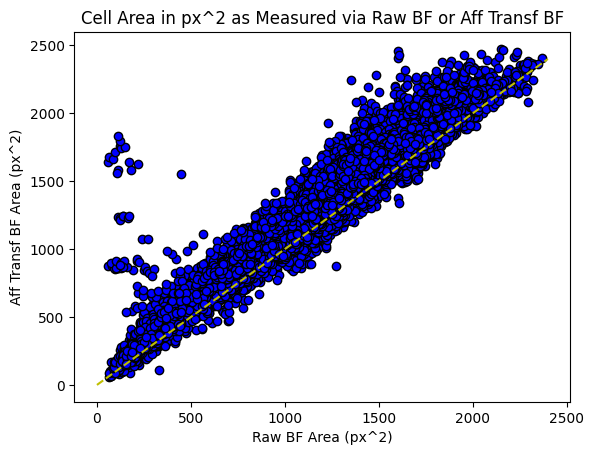

In [14]:
plt.figure()
plt.scatter(areas_arr[:,0],areas_arr[:,1],c='b',edgecolors='k')
plt.plot(np.arange(0,2500,100), np.arange(0,2500,100), c='y', ls='--')
plt.title('Cell Area in px^2 as Measured via Raw BF or Aff Transf BF')
plt.xlabel('Raw BF Area (px^2)')
plt.ylabel('Aff Transf BF Area (px^2)')

# plt.ylim(1700,1800)
# plt.xlim(1200,1300)

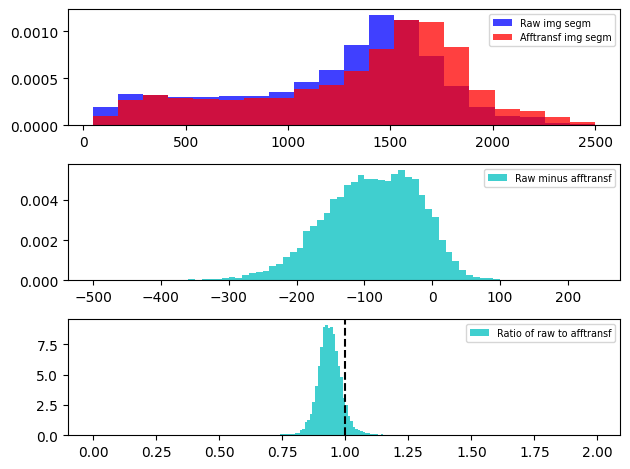

In [44]:
colors=['b','r','c','y','k']
fig,axes=plt.subplots(nrows=3,ncols=1)
# for i in range(vo_frames.shape[0]):

n0,b0,p0=axes[0].hist(rawmaskdata['cell_area_pxl'].values,bins='doane', alpha=0.75,density=True,label='Raw img segm', color=colors[0])
axes[0].hist((scale_factor**2)*affdf['area'].values,bins=b0, alpha=0.75,density=True,label='Afftransf img segm', color=colors[1])
# axes[0].hist((scale_factor**2)*expsndf['area'].values,bins=b0, alpha=0.75,density=True,label='Aff+expsn2 img segm', color=colors[3])
axes[1].hist(area_diffs,bins=np.arange(-500,250,10), alpha=0.75,density=True,label='Raw minus afftransf', color=colors[2])
axes[2].hist(area_ratios,bins=np.arange(0,2,.01), alpha=0.75,density=True,label='Ratio of raw to afftransf', color=colors[2])
axes[2].axvline(1, c='k', ls='--')
axes[0].legend(fontsize='x-small')
axes[1].legend(fontsize='x-small')
axes[2].legend(fontsize='x-small')
# axes[0].set_xlim(0,75)
# axes[1].set_xlim(0,25)    
# axes[2].set_xlim(0,2)
# fig.supxlabel('Cell Area (px)')
# fig.suptitle('Frame Pixel Distributions over Time (45 min intervals)')
fig.tight_layout()

In [15]:
julyrun=areas_arr

In [71]:
bothruns=np.concatenate([junerun,julyrun])

In [73]:
len(bothruns)

46723

### Linear regression on segmentation comparison datasets

In [ ]:
# %% Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
def linreg(dataset: np.ndarray, n: int=1000, train_frac=0.5, plot_graph=False):
    """
    Args: 2D Array of data to perform regression upon, number of runs, fraction of data to use for training, optional graph.
    Outputs: List of regression coeff scores.
    """
    scores =[]
    for run in range(n):
        train,test=train_test_split(dataset,test_size=0.5)
        reg=LinearRegression(fit_intercept=False).fit(train[:,0].reshape(-1,1),train[:,1].reshape(-1,1)) #reshaping to revert back to vertical array
        score=reg.score(test[:,0].reshape(-1,1),test[:,1].reshape(-1,1))
        scores.append(score)
        # scores.append(reg.coef_)
    return scores



In [20]:
# segm_scores=linreg(bothruns)
# june_scores=linreg(junerun)
july_scores=linreg(julyrun)

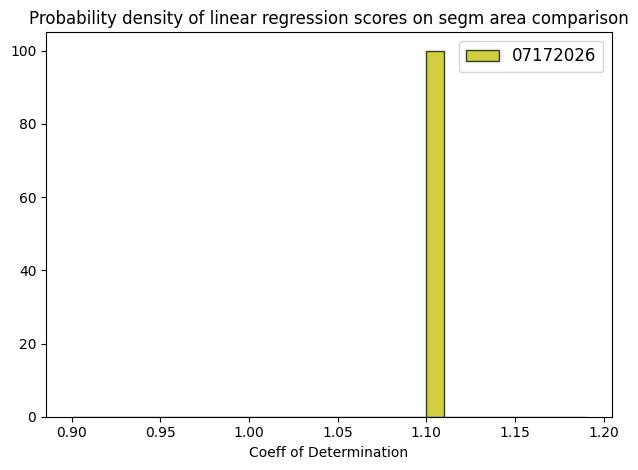

In [ ]:
fig,axes=plt.subplots(nrows=1,ncols=1)
n0,b0,p0=axes.hist(segm_scores,bins='doane', alpha=1, density=True, edgecolor='black', color='k', label='Both datasets')
n1,b1,p1=axes.hist(june_scores,bins=b0, alpha=0.75, density=True, edgecolor='black', color='r', label='06102026')
n2,b2,p2=axes.hist(july_scores,bins=b0, alpha=0.75, density=True, edgecolor='black', color='y', label='07172026')
axes.legend(fontsize='large')
axes.set_xlabel('Coeff of Determination')
axes.set_title('Probability density of linear regression scores on segm area comparison')
# axes.set_xlim([0,1])
fig.tight_layout()

### 07102026
1. Evaluating presence of photobleaching in first 3 hr run with five confocal captures.

In [5]:
ynb_path=r'C:\Users\jglic\Downloads\07102026 3c-ey2796\confynb-jg_07102026_ey2795_glucose-2.0_fov1.tif'
red_path=r'C:\Users\jglic\Downloads\07102026 3c-ey2796\confred-jg_07102026_ey2795_glucose-2.0_fov1.tif'
ynb_stack=io.imread(ynb_path) #shape of (5,40,1024,1024,2) corr to (t,z,y,x,c)
ld_img=io.imread(red_path)
vo_img,gl_img=ynb_stack[:,:,:,0],ynb_stack[:,:,:,1]

In [11]:
vo_frames=[]
gl_frames=[]
ld_frames=[]
for i in range(vo_img.shape[0]): #flatten each time frame
    vo_frames.append(vo_img[i,:,:,:].flatten())
    gl_frames.append(gl_img[i,:,:,:].flatten())
    ld_frames.append(ld_img[i,:,:,:].flatten())
vo_frames=np.array(vo_frames)
gl_frames=np.array(gl_frames)
ld_frames=np.array(ld_frames)

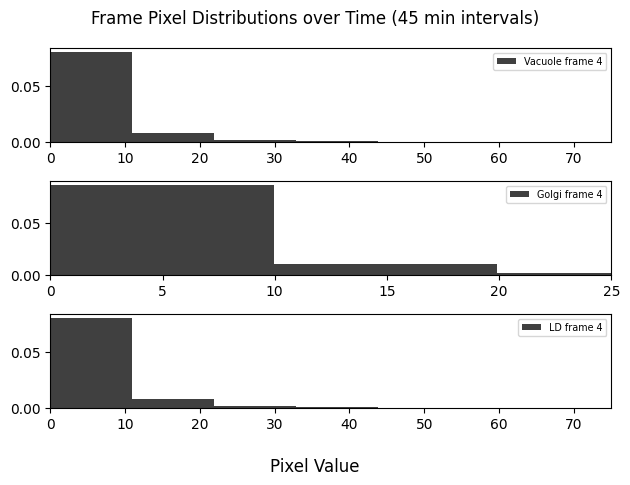

In [20]:
colors=['b','r','c','y','k']
fig,axes=plt.subplots(nrows=3,ncols=1)
# for i in range(vo_frames.shape[0]):
i=4
axes[0].hist(vo_frames[i,:],bins='doane', alpha=0.75,density=True,label='Vacuole frame '+str(i), color=colors[i])
axes[1].hist(gl_frames[i,:],bins='doane', alpha=0.75,density=True,label='Golgi frame '+str(i), color=colors[i])
axes[2].hist(vo_frames[i,:],bins='doane', alpha=0.75,density=True,label='LD frame '+str(i), color=colors[i])
axes[0].legend(fontsize='x-small')
axes[1].legend(fontsize='x-small')
axes[2].legend(fontsize='x-small')
axes[0].set_xlim(0,75)
axes[1].set_xlim(0,25)    
axes[2].set_xlim(0,75)
fig.supxlabel('Pixel Value')
fig.suptitle('Frame Pixel Distributions over Time (45 min intervals)')
fig.tight_layout()

In [2]:
csv_path=r'C:\Users\jglic\Downloads\12-16-2025 erg6-sec61 haploid\20251216_BF-timelapse_acdc_output_cpsam-d20_afftransf+HE.csv' 
df=pd.read_csv(csv_path)

In [3]:
df

,frame_i,Cell_ID,time_minutes,time_hours,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,...,moments_central-3-0,moments_central-3-1,moments_central-3-2,moments_central-3-3,bbox-0,bbox-1,bbox-2,bbox-3,velocity_pixel,velocity_um
0,0,1,0.0,0.000000,S,2.0,2.0,mother,-1.0,-1.0,...,-3177.077212,-51466.887559,96530.084818,-2.444086e+06,35,366,59,390,NaN,NaN
1,0,2,0.0,0.000000,S,0.0,1.0,bud,-1.0,-1.0,...,-3548.278236,32107.116838,131334.083260,1.495280e+06,44,350,63,369,NaN,NaN
2,0,3,0.0,0.000000,S,2.0,5.0,mother,-1.0,-1.0,...,1154.941432,-38660.474734,-169521.612087,-1.659762e+06,58,367,84,394,NaN,NaN
3,0,4,0.0,0.000000,S,2.0,9.0,mother,-1.0,-1.0,...,387.226685,-111878.936134,43328.014063,-5.100833e+06,61,395,85,414,NaN,NaN
4,0,5,0.0,0.000000,S,0.0,3.0,bud,-1.0,-1.0,...,970.937519,10586.147439,-69319.522173,4.217455e+05,62,348,82,368,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,23,112,115.0,1.916667,S,1.0,118.0,mother,20.0,20.0,...,3785.175133,-50376.120460,-86265.678801,-2.310588e+06,315,368,340,391,1.884416,0.408918
1297,23,114,115.0,1.916667,S,0.0,30.0,bud,21.0,-1.0,...,-1002.387312,24066.586231,27754.532238,6.932984e+05,304,246,322,265,3.054676,0.662865
1298,23,116,115.0,1.916667,S,0.0,4.0,bud,22.0,-1.0,...,258.277048,-168.835374,-1942.334800,-5.559206e+03,54,412,65,423,0.829521,0.180006
1299,23,118,115.0,1.916667,S,0.0,112.0,bud,22.0,-1.0,...,70.484933,3066.629740,5765.341559,9.457180e+04,322,351,338,368,0.461616,0.100171


In [ ]:
#Define function to take in dataframe and optional graph Title arg, and return # cells vs time graph.
def plot_numcells(df, Title=False):
    """Args:
       Outputs: 
    """
    plt.figure()
    # counts=0 #take only unique values from num_objects column. only poses a problem when non monotonic. 
    plt.plot(np.arange(0,len(counts),step=1), counts) #plot area as function of time
    plt.scatter(np.arange(0,len(counts),step=1),counts,label='all cells')
    plt.xlabel('Time (min)')
    plt.ylabel('# Cells')
    if Title==True:
        plt.title(input())
    # plt.legend()

#Define function to take in dataframe, start/stop bounds for Cell_IDs to consider, and optional graph Title arg, and return A(t) for each cell on same graph.
def plot_avt(df, rstart, rstop, Title=False):
    plt.figure() 
    for ID in np.arange(rstart,rstop,step=1): #for each Cell_ID in data...
        mask=df['Cell_ID'].values==ID #create a mask to extract that Cell_ID's rows
        ID_subset=df[mask] #apply mask
        plt.plot(ID_subset['time_minutes'].values,ID_subset['cell_area_pxl'].values) #plot area as function of time
        plt.scatter(ID_subset['time_minutes'].values,ID_subset['cell_area_pxl'].values, label='Cell_'+str(ID))
    plt.xlabel('Time (min)')
    plt.ylabel('Cell Area (px)')
    if Title==True:
        plt.title(input())
    # plt.legend()

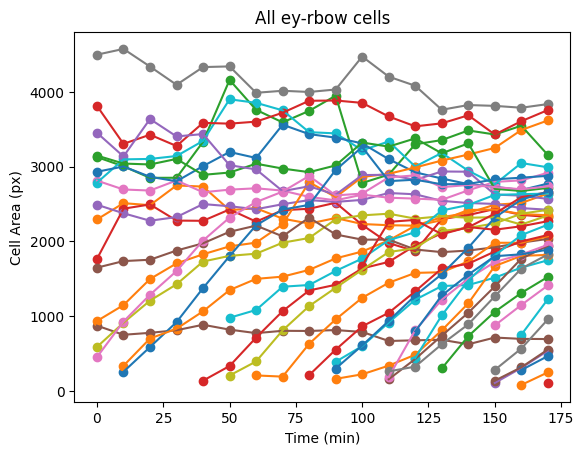

In [27]:
plot_avt(data,0,max(data.Cell_ID),Title=True)

In [37]:
# plot_avt(data,16,54,Title=True)